# Part 5

In [36]:
import redis
import pandas as pd
import matplotlib.pyplot as plt

REDIS_KEY_PREFIX = 'journey:gyro'

r = redis.Redis(host='localhost', port=6379)
keys = r.keys(f'{REDIS_KEY_PREFIX}:*')
print(f"Gefundene Keys in Redis: {len(keys)}")

Gefundene Keys in Redis: 27


In [37]:
records = []
for key in keys:
    data = r.hgetall(key)
    decoded = {k.decode('utf-8'): v.decode('utf-8') for k, v in data.items()}
    records.append(decoded)

df = pd.DataFrame(records)
df['avg_absolute']  = df['avg_absolute'].astype(float)
df['avg_gx']        = df['avg_gx'].astype(float)
df['avg_gy']        = df['avg_gy'].astype(float)
df['avg_gz']        = df['avg_gz'].astype(float)
df['n_samples']     = df['n_samples'].astype(int)
df['fenster_start'] = pd.to_datetime(df['fenster_start'])
df = df.sort_values('fenster_start').reset_index(drop=True)

print(f"Geladene Fenster: {len(df)}")
df[['fenster_start', 'avg_gx', 'avg_gy', 'avg_gz', 'avg_absolute', 'n_samples']].head(10)

Geladene Fenster: 27


,fenster_start,avg_gx,avg_gy,avg_gz,avg_absolute,n_samples
0,2026-05-30 17:34:42,-0.772951,-0.634365,0.332201,1.306312,100
1,2026-05-30 17:34:43,-2.636292,-1.008084,-0.302620,3.096817,99
2,2026-05-30 17:34:44,-2.720115,-1.239759,-0.325434,3.249203,99
3,2026-05-30 17:34:45,0.329835,0.049760,0.082236,0.910198,100
4,2026-05-30 17:34:46,0.168188,0.544998,-0.026692,1.005474,99
5,2026-05-30 17:34:47,-0.042918,-0.445427,-0.104124,0.491426,4
6,2026-05-30 17:36:18,0.041508,-0.043603,0.009474,0.062518,4
7,2026-05-30 17:36:19,-0.016042,-0.082148,0.179040,0.289126,99
8,2026-05-30 17:36:20,-0.211935,-0.060120,-0.110519,0.583788,100
9,2026-05-30 17:36:21,-0.178096,-0.067493,-0.094212,0.869280,99


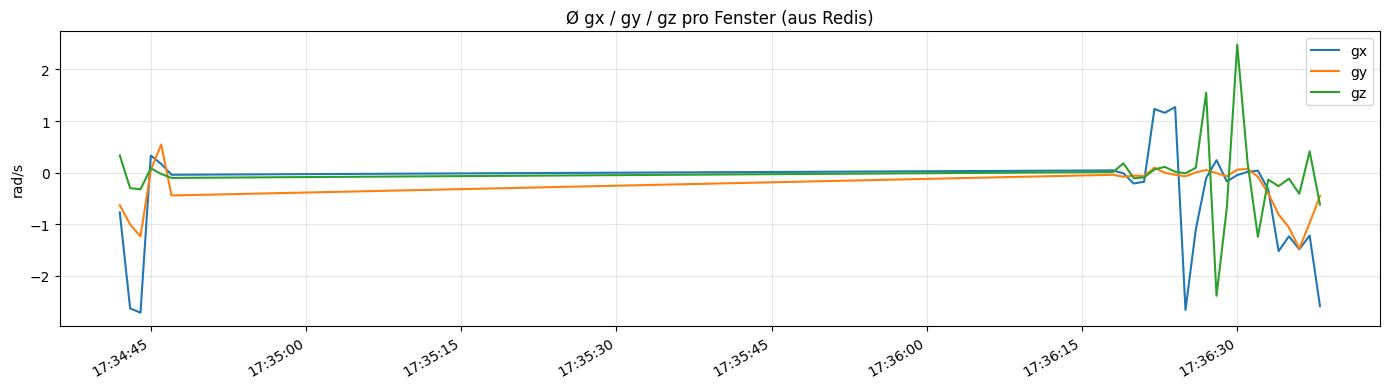

In [38]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df['fenster_start'], df['avg_gx'], label='gx')
ax.plot(df['fenster_start'], df['avg_gy'], label='gy')
ax.plot(df['fenster_start'], df['avg_gz'], label='gz')
ax.set_title('Ø gx / gy / gz pro Fenster (aus Redis)')
ax.set_ylabel('rad/s')
ax.legend()
ax.grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()
